# Caligo tutorial: a full haze-model run for GJ 1214 b

This notebook is a start-to-finish walkthrough of one full Caligo production run for GJ 1214 b. The idea is to build the model slowly enough that every setting makes sense, then let the full time-dependent haze calculation run all the way to convergence.

Caligo is a haze-microphysics model. It starts with an atmospheric background, uses photochem to calculate disequilibrium chemistry and photolysis rates, and then follows how haze particles are produced, transported, removed, and redistributed in size.

The full workflow is:

1. Set the planetary and stellar inputs.
2. Build a PICASO pressure-temperature profile.
3. Define the vertical mixing profile, $K_{zz}$.
4. Run photochem to calculate the disequilibrium chemistry.
5. Choose how haze is produced and what particle sizes it enters as.
6. Turn on the pieces of the microphysics model we want to include.
7. Build the microphysics context and make sure the setup looks reasonable.
8. Run the full time-dependent haze solver until the convergence criteria are met.
9. Save the expensive result and make the main diagnostic plots.

We will use three related pressure grids along the way:

- A broad PICASO background grid, which gives us the full atmospheric structure.
- A photochem grid, which follows the gas chemistry through the upper atmosphere.
- A Caligo microphysics grid, which focuses on the region where the haze calculation is most useful.

For this example, the PICASO background spans roughly $10^{3}$ to $10^{-7}$ bar. The microphysics calculation uses a smaller working domain, roughly $10$ to $10^{-10}$ bar. That gives the particles room to form high in the atmosphere, grow as they move downward, and reach the warmer layers where removal becomes important.

This is intentionally a full production notebook, not a quick smoke test. Once the solver starts, the haze integration may take several hours.

## 1. Start with the local setup

This first cell points the notebook to the local Caligo project and reference-data folders. These are the only paths that should need editing when the notebook is moved to a different computer.

The Caligo interface is intentionally similar to PICASO. We will import `caligo.justdoit` as `cdi`, then build the model using a sequence of readable setup calls.

In [4]:
from pathlib import Path
import os
import sys
import time
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import display

from astropy import constants as const
from astropy import units as u

PROJECT_ROOT = Path("/Users/svc553/Documents/Caligo")
PYSYN_CDBS = Path("/Users/svc553/Documents/Reference_Data/grp_Phoenix/redcat/trds")
PICASO_REFDATA = Path("/Users/svc553/Documents/Picaso/reference")

RUN_LABEL = "gj1214b_full_production"

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ["PYSYN_CDBS"] = str(PYSYN_CDBS)
os.environ["picaso_refdata"] = str(PICASO_REFDATA)

import picaso.photochem as picasochem
import caligo.justdoit as cdi
from caligo import background as cb
from caligo import diagnostics as diag
from caligo import microphysics as cm
from caligo import optics as copt


importlib.reload(cb)
importlib.reload(cm)
importlib.reload(diag)
importlib.reload(copt)


print("Caligo is ready.")
print("Project folder:", PROJECT_ROOT)
print("Working directory:", Path.cwd())

Caligo is ready.
Project folder: /Users/svc553/Documents/Caligo
Working directory: /Users/svc553/Documents/Caligo


## 2. Make the photochem input files

Photochem needs a reaction network and a thermodynamic-data file. PICASO includes a helper that generates the default YAML files used by this workflow.

We also point photochem to the stellar spectrum for GJ 1214. That file sets the wavelength-dependent stellar irradiation used in the photochemistry calculation.

In [5]:
picasochem.generate_photochem_rx_and_thermo_files()

MECHANISM_FILE = "photochem_rxns.yaml"
THERMO_FILE = "photochem_thermo.yaml"
STELLAR_FLUX_FILE = "data/stellar_flux/GJ1214_test.txt"

required_files = [
    MECHANISM_FILE,
    THERMO_FILE,
    STELLAR_FLUX_FILE,
]

print("Checking the photochem input files:")

for filename in required_files:
    exists = Path(filename).exists()
    print(f"  {filename}: {exists}")
    assert exists, f"Missing required file: {filename}"

Checking the photochem input files:
  photochem_rxns.yaml: True
  photochem_thermo.yaml: True
  data/stellar_flux/GJ1214_test.txt: True


## 3. Add the basic GJ 1214 b inputs

Now we set the planetary radius, planetary mass, equilibrium temperature, intrinsic temperature, orbital separation, and host-star properties.

The pressure bounds are also worth thinking about here. The PICASO profile should extend deeper than the part of the atmosphere we eventually use for haze microphysics. We are using a lower boundary near $10^{3}$ bar for the background atmosphere, even though the haze solver itself will stop much higher, near $10$ bar.

That broader background gives photochem a physically useful atmosphere to initialize from without making the later microphysics grid unnecessarily expensive.

In [6]:
r_planet = (0.2438 * const.R_jup).to(u.cm).value
m_planet = (0.0265 * const.M_jup).to(u.g).value

planet_Teq = 567.0
planet_tint = 30.0
semi_major_AU = 0.01505

stellar_radius_Rsun = 0.2162
stellar_Teff = 3101.0
stellar_metal = 0.24
stellar_logg = 5.0286

CLIMATE_P_BOTTOM_LOG10 = 3.0
CLIMATE_P_TOP_LOG10 = -7.0
CLIMATE_NLEVEL = 141

PHOTOCHEM_NZ = 120
PHOTOCHEM_METALLICITY = 100.0
PHOTOCHEM_CTO_RELATIVE = 1.0

NZ_TARGET = 50
P_TOP_MICRO = 1e-10
P_BOT_MICRO = 10.0

print("GJ 1214 b setup")
print("Planet radius [cm]:", r_planet)
print("Planet mass [g]:", m_planet)
print("PICASO pressure range [bar]:",
      10**CLIMATE_P_TOP_LOG10, "to", 10**CLIMATE_P_BOTTOM_LOG10)
print("Caligo pressure range [bar]:", P_TOP_MICRO, "to", P_BOT_MICRO)

GJ 1214 b setup
Planet radius [cm]: 1742974959.9999998
Planet mass [g]: 5.030030182940533e+28
PICASO pressure range [bar]: 1e-07 to 1000.0
Caligo pressure range [bar]: 1e-10 to 10.0


## 4. Initialize the PICASO atmosphere

We can now make the Caligo case and load the PICASO opacity connection.

The gas list below is the set of species we want preloaded for the atmospheric background and any later radiative-transfer work. The haze microphysics calculation itself does not need all of these opacity species, but keeping the connection ready makes the notebook easier to build on later.

The gravity, intrinsic temperature, and stellar inputs are stored inside the Caligo case so the later photochem and microphysics steps can reuse them.

In [7]:
gases_fly = [
    "H2O",
    "NH3",
    "CO2",
    "N2",
    "HCN",
    "H2",
    "C2H2",
    "C2H4",
    "C2H6",
]

print("Loading the PICASO opacity connection...")
start = time.time()

opacity_ck = cdi.opannection(
    method="resortrebin",
    preload_gases=gases_fly,
)

print(f"Opacity connection loaded in {time.time() - start:.2f} s")

case = cdi.inputs(calculation="planet", climate=True)

case.gravity(
    radius=r_planet,
    radius_unit=u.cm,
    mass=m_planet,
    mass_unit=u.g,
)

case.effective_temp(planet_tint)

case.star(
    opacity_ck,
    temp=stellar_Teff,
    metal=stellar_metal,
    logg=stellar_logg,
    radius=stellar_radius_Rsun,
    radius_unit=u.R_sun,
    semi_major=semi_major_AU,
    semi_major_unit=u.AU,
    database="phoenix",
)

print("The Caligo case is initialized.")

Loading the PICASO opacity connection...


/opt/anaconda3/envs/caligo/lib/python3.12/site-packages/picaso/optics.py:1410: UserWarning: Warning: npy files for DEQ will be deprecated in a future PICASO udpate. Please download the hdf5 files, explanation here https://natashabatalha.github.io/picaso/notebooks/climate/12c_BrownDwarf_DEQ.html
  warnings.warn(' '.join(np.unique(msg)), UserWarning)


Opacity connection loaded in 0.26 s
The Caligo case is initialized.


## 5. Build a PICASO pressure-temperature profile

The pressure-temperature profile is the background atmosphere that everything else sits on top of.

For this tutorial, we use PICASO's Guillot-profile helper. This is a simple and convenient starting point. The resulting profile is cached inside the Caligo case and passed into photochem in the next part of the notebook.

Pressure-temperature profile created.


,temperature,pressure
0,488.286691,1.000000e-07
1,488.286768,1.178769e-07
2,488.286856,1.389495e-07
3,488.286967,1.637894e-07
4,488.287095,1.930698e-07


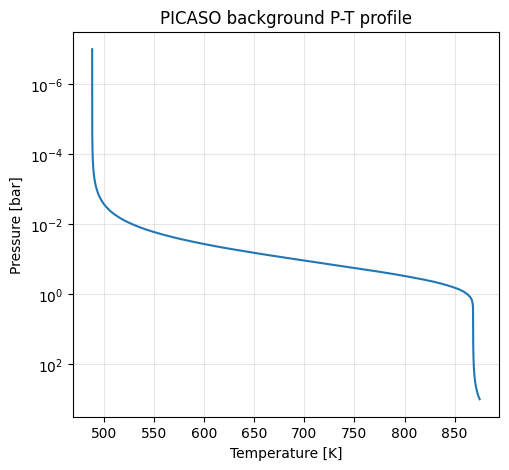

In [8]:
pt = case.guillot_pt(
    Teq=planet_Teq,
    nlevel=CLIMATE_NLEVEL,
    T_int=planet_tint,
    p_bottom=CLIMATE_P_BOTTOM_LOG10,
    p_top=CLIMATE_P_TOP_LOG10,
)

case.inputs_climate(
    temp_guess=pt["temperature"].values,
    pressure=pt["pressure"].values,
    nstr=[0, 120, 139, 0, 0, 0],
    nofczns=1,
    rfacv=0.5,
)

print("Pressure-temperature profile created.")
display(pt.head())

fig, ax = plt.subplots(figsize=(5.5, 5.0))
ax.plot(pt["temperature"], pt["pressure"])
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Pressure [bar]")
ax.set_title("PICASO background P-T profile")
ax.grid(alpha=0.3)
plt.show()

## 6. Decide how strongly the atmosphere mixes

The eddy-diffusion coefficient, $K_{zz}$, controls vertical mixing. A larger value means that gas and haze particles are redistributed more efficiently between pressure levels.

Caligo lets us define $K_{zz}$ in a few ways:

- Use one constant value through the whole atmosphere.
- Pass in a custom profile.
- Use a smooth three-zone profile with separate upper, middle, and deep values.

We are using the three-zone option here. The upper atmosphere is more strongly mixed, while the middle and deep atmosphere use a lower value.

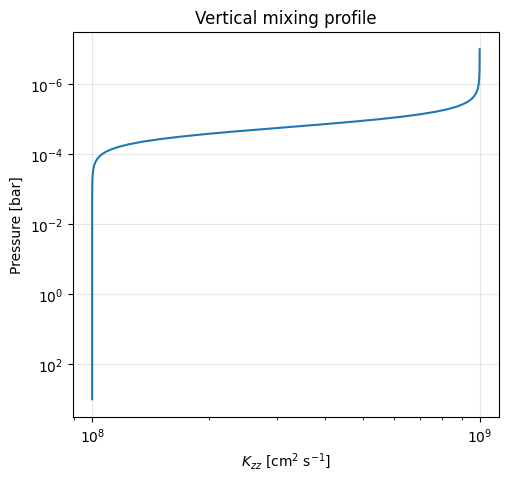

In [9]:
KZZ_UPPER = 1e9
KZZ_MID = 1e8
KZZ_DEEP = 1e8

KZZ_BREAK_TOP_BAR = 1e-5
KZZ_BREAK_DEEP_BAR = 30.0
KZZ_WIDTH_DEX = 0.4

KZZ_MICRO_SCALE = 1.0

case.kzz(
    upper=KZZ_UPPER,
    mid=KZZ_MID,
    deep=KZZ_DEEP,
    break_top_bar=KZZ_BREAK_TOP_BAR,
    break_deep_bar=KZZ_BREAK_DEEP_BAR,
    width_dex=KZZ_WIDTH_DEX,
)

kzz_background = cb.kzz_profile_from_settings(
    pt["pressure"].values,
    case.kzz_settings,
)

fig, ax = plt.subplots(figsize=(5.5, 5.0))
ax.plot(kzz_background, pt["pressure"].values)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel(r"$K_{zz}$ [cm$^2$ s$^{-1}$]")
ax.set_ylabel("Pressure [bar]")
ax.set_title("Vertical mixing profile")
ax.grid(alpha=0.3)
plt.show()

## 7. Set up the disequilibrium chemistry calculation

The next piece is photochem. This is where we calculate the gas chemistry away from simple equilibrium.

A few settings are especially useful to keep in mind:

- The reaction-network file controls which reactions and species are available.
- The thermodynamic-data file supplies the species properties.
- The stellar spectrum controls the photochemistry.
- The metallicity changes the atmospheric enrichment.
- The carbon-to-oxygen ratio changes the bulk composition.
- The $K_{zz}$ profile affects how efficiently material is mixed through the atmosphere.

Those choices can change both the gas abundances and the photolysis rates that eventually feed the haze model.

In [10]:
case.photochem(
    mechanism_file=MECHANISM_FILE,
    thermo_file=THERMO_FILE,
    stellar_flux_file=STELLAR_FLUX_FILE,
    nz=PHOTOCHEM_NZ,
    P_ref=1e7,
    TOA_pressure=1e-4,
    metallicity=PHOTOCHEM_METALLICITY,
    cto_relative=PHOTOCHEM_CTO_RELATIVE,
    chem_method="photochem+visscher",
)

print("Photochem settings are attached to the case.")

for key, value in case.photochem_settings.items():
    print(f"  {key}: {value}")

Photochem settings are attached to the case.
  mechanism_file: photochem_rxns.yaml
  thermo_file: photochem_thermo.yaml
  stellar_flux_file: data/stellar_flux/GJ1214_test.txt
  nz: 120
  P_ref: 10000000.0
  TOA_pressure: 0.0001
  metallicity: 100.0
  cto_relative: 1.0
  chem_method: photochem+visscher
  photochem_init_args: {'mechanism_file': 'photochem_rxns.yaml', 'thermo_file': 'photochem_thermo.yaml', 'stellar_flux_file': 'data/stellar_flux/GJ1214_test.txt', 'nz': 120, 'P_ref': 10000000.0, 'TOA_pressure': 0.0001}


## 8. Run photochem and take a quick look at the output

This is the first step that may take a little time.

Photochem starts from the PICASO background, initializes the composition, and searches for a steady-state disequilibrium solution. The result includes the gas abundances and altitude-dependent photolysis rates that Caligo can use as a haze source.

The species check at the end is a quick way to confirm that the precursor molecules we care about are actually present in the reaction network.

In [11]:
print("Running photochem...")
start = time.time()

pc, Pbar_pc, z_pc, T_pc = case.run_photochem(find_steady_state=True)

print(f"Photochem finished in {(time.time() - start) / 60.0:.2f} min")
print("Pressure range [bar]:", np.min(Pbar_pc), "to", np.max(Pbar_pc))
print("Altitude range [cm]:", np.min(z_pc), "to", np.max(z_pc))
print("Temperature range [K]:", np.min(T_pc), "to", np.max(T_pc))
print("Number of photochem levels:", len(Pbar_pc))

species_names = list(pc.dat.species_names)
check_species = ["HCN", "C2H2", "CH4", "CO", "H2O", "CO2"]

print("\nSelected species in the reaction network:")

for species in check_species:
    print(f"  {species}: {species in species_names}")

print("\nFirst 40 species names:")
print(species_names[:40])

Running photochem...

CALIGO: PHOTOCHEM STEADY STATE
Photochem input P range = [1.000e-07, 1.000e+03] bar
Photochem input T range = [488.3, 874.9] K
Photochem input Kzz range = [1.000e+08, 1.000e+09] cm^2/s
metallicity = 100.0
C/O passed to photochem = 1.0
Running pc.find_steady_state()...
nsteps = 100  longdy = 9.0e-01  max_dT = 1.2e+00  max_dlog10edd = 2.1e-02  TOA_pressure = 1.3e-10
nsteps = 200  longdy = 9.8e+01  max_dT = 1.2e+00  max_dlog10edd = 2.1e-02  TOA_pressure = 1.8e-10
nsteps = 300  longdy = 4.7e+04  max_dT = 1.2e+00  max_dlog10edd = 2.1e-02  TOA_pressure = 2.1e-10


KeyboardInterrupt: 

# Part II: add the haze microphysics

At this point we have an atmospheric background and a disequilibrium-chemistry solution. Now we can build the actual haze model.

The microphysics solver follows a few connected processes:

1. New haze material enters the atmosphere.
2. That mass is converted into a number of freshly formed particles.
3. Coagulation shifts mass from smaller particles into larger particles.
4. Diffusion and settling move particles vertically.
5. Warm deep layers remove haze through a parameterized thermal-destruction sink.
6. The time-dependent solver keeps going until the source, sinks, and particle profile become stable enough to call the result converged.

The next cells keep those choices separate so it is easy to see what each setting is doing.

## 9. Pick the microphysics grid and particle-size grid

The microphysics grid is the pressure range where Caligo actually evolves the haze particles. It does not need to cover the entire PICASO atmosphere.

The particle grid is sectional. Instead of tracking every possible radius continuously, Caligo stores the particle population in a set of mass bins. Each neighboring bin differs in mass by a fixed factor.

For this baseline:

- We use 50 atmospheric levels.
- The microphysics grid runs from about $10$ to $10^{-10}$ bar.
- The smallest compact particle has a radius of 1 nm.
- The particle grid contains 40 bins.
- Neighboring bins differ in mass by a factor of 2.

That gives the model room to follow particles from very small fresh seeds into much larger coagulated particles.

In [ ]:
case.microphysics_grid(
    nz_target=NZ_TARGET,
    p_top_micro=P_TOP_MICRO,
    p_bot_micro=P_BOT_MICRO,
    kzz_micro_scale=KZZ_MICRO_SCALE,
)

case.particles(
    n_bin=40,
    rho_haze=1.0,
    r_monomer_nm=1.0,
    bin_mass_ratio=2.0,
)

print("Microphysics grid:")
for key, value in case.microphysics_grid_settings.items():
    print(f"  {key}: {value}")

print("\nParticle grid:")
for key, value in case.particle_settings.items():
    print(f"  {key}: {value}")

Microphysics grid:
  nz_target: 50
  p_top_micro: 1e-10
  p_bot_micro: 10.0
  kzz_micro_scale: 1.0

Particle grid:
  n_bin: 40
  rho_haze: 1.0
  r_monomer_nm: 1.0
  bin_mass_ratio: 2.0


## 10. Decide how new haze enters the atmosphere

There are two separate questions here:

1. Where is haze produced vertically?
2. What size are the particles when that new material first enters the particle grid?

For the vertical profile, Caligo can use either:

- **photochem**: follow the altitude-dependent photolysis profile from selected precursor molecules.
- **gaussian**: place a controlled Gaussian source at a chosen pressure and width.

The photochem option is the more physically coupled choice. The Gaussian option is useful for controlled experiments because it lets us move the source layer around without rerunning the chemistry.

For a photochemical source, we also choose how to handle material near the edge of the microphysics grid:

- **split top flux** keeps the in-domain source and adds material produced above the grid as a downward top-boundary flux.
- **in domain only** keeps only the source inside the working grid.
- **renormalize in domain** keeps the in-domain shape but rescales it to the selected total haze flux.

The yield model decides how much effective haze mass is associated with one photolyzed precursor molecule. In this tutorial, we use the full parent-molecule mass multiplied by a haze yield. That keeps the conversion simple while still acknowledging that only part of the photolyzed material becomes stable aerosol.

Finally, the fresh-particle setting decides the initial size distribution. The simplest baseline is to place all newly formed haze into the smallest bin and let coagulation build the larger particles naturally.

In [ ]:
SOURCE_VERTICAL_MODE = "photochem"
SOURCE_COUPLING_MODE = "split_top_flux"

HAZE_PARENTS = ["HCN", "C2H2"]
USE_ALL_PHOTOLYSIS = False

SOURCE_YIELD_MODEL = "parent_molecular_mass"
YIELD_HAZE = 0.10

USE_FIXED_FLUX = True
TARGET_HAZE_FLUX = 1.0e-13
SOURCE_FLUX_SCALE = 1.0

GAUSS_PEAK_BAR = 1.0e-7
GAUSS_SIGMA_DEX = 0.50

SOURCE_BIN_MODE = "single_bin"
SOURCE_BIN_INDEX = 0
SOURCE_R0_NM = 2.0
SOURCE_SIGMA_DEX = 0.20
SOURCE_BIN_WEIGHTS = None

case.haze_source(
    vertical_mode=SOURCE_VERTICAL_MODE,
    coupling_mode=SOURCE_COUPLING_MODE,
    parents=HAZE_PARENTS,
    use_all_photolysis=USE_ALL_PHOTOLYSIS,
    yield_model=SOURCE_YIELD_MODEL,
    yield_haze=YIELD_HAZE,
    use_fixed_flux=USE_FIXED_FLUX,
    target_haze_flux=TARGET_HAZE_FLUX,
    source_flux_scale=SOURCE_FLUX_SCALE,
    gauss_peak_bar=GAUSS_PEAK_BAR,
    gauss_sigma_dex=GAUSS_SIGMA_DEX,
    bin_mode=SOURCE_BIN_MODE,
    bin_index=SOURCE_BIN_INDEX,
    r0_nm=SOURCE_R0_NM,
    sigma_dex=SOURCE_SIGMA_DEX,
    bin_weights=SOURCE_BIN_WEIGHTS,
)

print("Haze source settings:")
for key, value in case.haze_source_settings.items():
    print(f"  {key}: {value}")

Haze source settings:
  vertical_mode: photochem
  coupling_mode: split_top_flux
  parents: ['HCN', 'C2H2']
  use_all_photolysis: False
  yield_model: parent_molecular_mass
  yield_haze: 0.1
  use_fixed_flux: True
  target_haze_flux: 1e-13
  source_flux_scale: 1.0
  gauss_peak_bar: 1e-07
  gauss_sigma_dex: 0.5
  bin_mode: single_bin
  bin_index: 0
  r0_nm: 2.0
  sigma_dex: 0.2
  bin_weights: None


## 11. Build the raw photochemical haze source

Before running the microphysics solver, it is helpful to see what the chemistry is giving us.

This cell builds the raw photochemical haze source and prints:

- the available photolysis parents,
- the precursor species we selected,
- the total raw haze-production flux,
- the contribution from each selected precursor,
- the effective haze mass assigned to each photolyzed molecule.

Even if we later choose a Gaussian source for a controlled experiment, this is still a useful chemistry diagnostic.


CALIGO: PHOTOCHEM HAZE SOURCE
Photolysis haze precursors: ['C2H2', 'HCN']
Source yield model = parent_molecular_mass
Yield haze = 0.1
Raw haze source flux = 5.980e-13 g cm^-2 s^-1
      C2H2: 1.138e-13 (0.19), haze mass per photolyzed molecule = 4.324e-24 g
       HCN: 4.842e-13 (0.81), haze mass per photolyzed molecule = 4.488e-24 g
Source peak P = 7.076e-09 bar, z = 2.868e+08 cm
Available photolysis parents:
['C2H2', 'C2H4', 'C2H6', 'C3H6', 'C4H2', 'C4H4', 'CH2CO', 'CH2N2', 'CH3CHO', 'CH3CN', 'CH3OH', 'CH4', 'CO', 'CO2', 'CS', 'CS2', 'H2', 'H2CO', 'H2O', 'H2O2', 'H2S', 'H2SO4', 'HCCCN', 'HCN', 'HNCO', 'HNO3', 'HO2', 'HS', 'HSO', 'N2', 'N2H4', 'N2O', 'NH3', 'NO', 'NO2', 'O2', 'O3', 'OCS', 'S2', 'S3', 'S4', 'SO', 'SO2', 'SO3']

Selected haze precursors:
['C2H2', 'HCN']

Raw photochemical source:
  Total flux [g cm^-2 s^-1]: 5.980004076433918e-13
  Species contributions: {'C2H2': 1.1379948144871735e-13, 'HCN': 4.842009261946743e-13}
  Effective mass by species: {'C2H2': 4.3237016598728

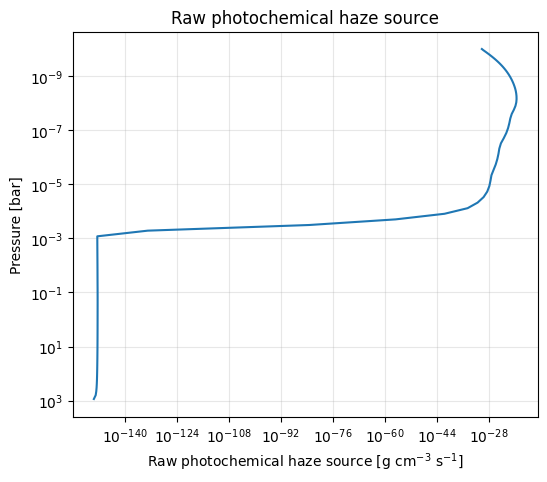

In [ ]:
source_info = case.build_haze_source()

print("Available photolysis parents:")
print(source_info["parents_all"])

print("\nSelected haze precursors:")
print(source_info["precursors"])

print("\nRaw photochemical source:")
print("  Total flux [g cm^-2 s^-1]:", source_info["F_photochem_raw"])
print("  Species contributions:", source_info["species_flux"])
print("  Effective mass by species:", source_info["species_effective_mass"])

fig, ax = plt.subplots(figsize=(6.0, 5.0))
ax.plot(
    np.maximum(source_info["q_raw"], 1e-300),
    source_info["Pbar_src_sorted"],
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel(r"Raw photochemical haze source [g cm$^{-3}$ s$^{-1}$]")
ax.set_ylabel("Pressure [bar]")
ax.set_title("Raw photochemical haze source")
ax.grid(alpha=0.3)
plt.show()

## 12. Choose compact particles or fluffy aggregates

Particles do not necessarily stay compact as they grow. They can become porous aggregates made of smaller primary particles stuck together.

That changes the model in two important ways:

- Aggregates can have a larger collision cross-section than compact particles of the same mass.
- Aggregates can settle differently because their effective density and drag radius change.

Turning aggregates off gives a clean compact-sphere comparison. Turning them on lets the fractal dimension vary with pressure.

For this baseline, the particles are more compact-like at low pressure and approach a fractal dimension near 2 deeper in the atmosphere.

In [ ]:
USE_AGGREGATES = True

case.aggregates(
    use=USE_AGGREGATES,
    df_fixed=2.0,
    r_primary_nm=10.0,
    k0=1.0,
    pressure_dependent=True,
    transition_p_bar=1.0e-6,
    transition_width_dex=0.5,
    use_agg_in_settling=True,
    use_agg_in_coag=True,
    collision_radius_cap_factor=None,
)

print("Aggregate settings:")
for key, value in case.aggregate_settings.items():
    print(f"  {key}: {value}")

Aggregate settings:
  use: True
  df_fixed: 2.0
  r_primary_nm: 10.0
  k0: 1.0
  pressure_dependent: True
  transition_p_bar: 1e-06
  transition_width_dex: 0.5
  use_agg_in_settling: True
  use_agg_in_coag: True
  collision_radius_cap_factor: None


## 13. Turn on particle growth through coagulation

Coagulation is how the model moves haze mass from small particles into larger particles.

The baseline uses Brownian coagulation, which comes from random thermal motion. Caligo can also add differential-settling collisions, where particles of different sizes fall at different speeds and run into one another.

Charge suppression is optional. When it is on, similarly charged particles repel one another, which lowers the collision rate.

A few useful comparison runs later are:

- coagulation on versus off,
- charged versus neutral particles,
- Brownian-only growth versus Brownian plus differential settling.

In [ ]:
case.coagulation(
    use=True,
    brownian=True,
    differential_settling=False,
    differential_settling_collision_efficiency=1.0,
    kernel_scale=1.0,
    charge_suppression=True,
    charge_density_e_per_um=15.0,
    substep_frac=0.03,
    max_substeps=10000,
    fixed_point_iters=4,
    skip_ntot=1e2,
    skip_mass_dens=1e-30,
    skip_dtl=1e-3,
    active_rel=1e-8,
    mass_err_warn=1e-6,
    top_overflow_mode="mass_conserve",
    retry_on_coag_substep_cap=True,
)

print("Coagulation settings:")
for key, value in case.coagulation_settings.items():
    print(f"  {key}: {value}")

Coagulation settings:
  use: True
  brownian: True
  differential_settling: False
  differential_settling_collision_efficiency: 1.0
  kernel_scale: 1.0
  charge_suppression: True
  charge_density_e_per_um: 15.0
  substep_frac: 0.03
  max_substeps: 10000
  fixed_point_iters: 4
  skip_ntot: 100.0
  skip_mass_dens: 1e-30
  skip_dtl: 0.001
  active_rel: 1e-08
  mass_err_warn: 1e-06
  top_overflow_mode: mass_conserve
  retry_on_coag_substep_cap: True


## 14. Add vertical transport and deep-atmosphere removal

Particles move through the atmosphere because of diffusion and gravitational settling.

The lower boundary can be handled in a few ways:

- **deposition velocity** removes particles using the larger of their settling speed and $K_{zz}/H$.
- **open flux** removes particles through settling only.
- **zero flux** closes the lower boundary.

We use the deposition-velocity option for the baseline.

The model also includes a smooth thermal-destruction sink. It turns on in warm deep layers and removes haze on a chosen timescale. This is a parameterized sink, not a detailed material-specific ablation model.

Caligo can move destroyed haze into a passive recycled-gas tracer. That tracer is useful for bookkeeping, but it is not yet chemically coupled back into photochem.

In [ ]:
case.transport(
    settling=True,
    settling_scale=1.0,
    bottom_bc="deposition_velocity",
    sedimentation_cfl=0.60,
    max_sedimentation_substeps=10000,
    transport_active_frac=1e-24,
)

case.sinks(
    thermal_model="finite_rate_smooth_T",
    therm_destroy_t_on_k=650.0,
    therm_destroy_width_k=100.0,
    therm_destroy_timescale=1.0e5,
    enable_recycling_to_gas=False,
    recycled_gas_label="passive_recycled_haze_mass",
    recycle_gas_diffusion=False,
    use_deep_recycling=False,
    deep_recycling_p_on_bar=1.0e-3,
    deep_recycling_width_dex=0.5,
    deep_recycling_timescale=1.0e6,
    deep_recycling_to_gas=False,
)

print("Transport settings:")
for key, value in case.transport_settings.items():
    print(f"  {key}: {value}")

print("\nSink settings:")
for key, value in case.sink_settings.items():
    print(f"  {key}: {value}")

Transport settings:
  settling: True
  settling_scale: 1.0
  bottom_bc: deposition_velocity
  sedimentation_cfl: 0.6
  max_sedimentation_substeps: 10000
  transport_active_frac: 1e-24

Sink settings:
  thermal_model: finite_rate_smooth_T
  therm_destroy_t_on_k: 650.0
  therm_destroy_width_k: 100.0
  therm_destroy_timescale: 100000.0
  enable_recycling_to_gas: False
  recycled_gas_label: passive_recycled_haze_mass
  recycle_gas_diffusion: False
  use_deep_recycling: False
  deep_recycling_p_on_bar: 0.001
  deep_recycling_width_dex: 0.5
  deep_recycling_timescale: 1000000.0
  deep_recycling_to_gas: False


## 15. Set the full production solver controls

Now we choose the settings for the actual time integration.

The solver starts with an empty haze atmosphere and adds newly produced particles over time. Within each step, Caligo applies source injection, coagulation, diffusion, settling, thermal destruction, and any optional deep removal. The timestep grows adaptively as the solution becomes easier to evolve.

Instead of stopping after a fixed physical time, the model checks whether the source, sinks, storage rate, vertical profile, and pressure of the haze peak have stabilized. We require the criteria to stay satisfied for several consecutive chunks before calling the result converged.

These are the full production settings used for the long GJ 1214 b run. This is the expensive part of the notebook, so the calculation may take several hours once coagulation becomes active.

In [ ]:
SOLVER = {
    "dt_init": 1e2,
    "dt_growth": 1.03,
    "dt_max": 300.0,
    "chunk_time": 1.0e5,
    "max_chunks": 200,
    "max_step_retries": 10,
    "retry_shrink": 0.5,
    "max_column_jump_frac": 1.0,
    "ss_tol_storage": 0.08,
    "ss_tol_balance": 0.25,
    "ss_tol_profile": 0.04,
    "ss_tol_peak_dex": 0.25,
    "ss_min_stable_chunks": 3,
    "allow_quasi_steady_stop": False,
    "enable_diagnostic_stop": False,
}

case.solver(**SOLVER)

print("Full production solver settings are attached to the case.")
print("Maximum allowed model time [days]:",
      SOLVER["chunk_time"] * SOLVER["max_chunks"] / 86400.0)

for key, value in case.solver_settings.items():
    print(f"  {key}: {value}")

Full production solver settings are attached to the case.
Maximum allowed model time [days]: 231.4814814814815
  dt_init: 100.0
  dt_growth: 1.03
  dt_max: 300.0
  chunk_time: 100000.0
  max_chunks: 200
  max_step_retries: 10
  retry_shrink: 0.5
  max_column_jump_frac: 1.0
  ss_tol_storage: 0.08
  ss_tol_balance: 0.25
  ss_tol_profile: 0.04
  ss_tol_peak_dex: 0.25
  ss_min_stable_chunks: 3
  allow_quasi_steady_stop: False
  enable_diagnostic_stop: False


## 16. Build the microphysics context before starting the long run

This is the quick safety check before we commit to the expensive calculation.

Building the context is fast. It gives us a chance to inspect the source profile, particle bins, aggregate geometry, settling speeds, coagulation kernel, and thermal sink before the time integration starts.

This is the moment to stop if the pressure domain looks wrong, the source is missing, or any arrays are non-finite. It is not a separate smoke run. It is just a quick inspection of the actual production setup.

In [ ]:
print("Preparing the microphysics context...")
start = time.time()

ctx = case.prepare_microphysics(with_coagulation=True)

print(f"Context prepared in {time.time() - start:.2f} s")
print("Atmospheric levels:", ctx["nz"])
print("Particle bins:", ctx["n_bin"])
print("Pressure range [bar]:", np.min(ctx["Pbar"]), "to", np.max(ctx["Pbar"]))
print("Temperature range [K]:", np.min(ctx["T"]), "to", np.max(ctx["T"]))
print("Kzz range [cm^2/s]:", np.min(ctx["Kzz"]), "to", np.max(ctx["Kzz"]))
print("Final haze-source flux [g cm^-2 s^-1]:", ctx["F_src"])
print("Source weights sum:", np.sum(ctx["source_weights"]))
print("Fresh-particle bins:", np.where(ctx["source_weights"] > 0)[0])
print("Compact radius range [nm]:",
      np.min(ctx["r_compact_nm"]), "to", np.max(ctx["r_compact_nm"]))
print("Maximum settling speed [cm/s]:", np.max(ctx["v_set"]))
print("Maximum coagulation kernel [cm^3/s]:", np.max(ctx["K_coag"]))

checks = {
    "Altitude increases upward": np.all(np.diff(ctx["z"]) > 0),
    "Pressure decreases upward": np.all(np.diff(ctx["Pbar"]) < 0),
    "Source flux is positive": ctx["F_src"] > 0,
    "Source weights sum to one": np.isclose(np.sum(ctx["source_weights"]), 1.0),
    "Settling speeds are finite": np.all(np.isfinite(ctx["v_set"])),
    "Settling speeds are non-negative": np.all(ctx["v_set"] >= 0),
    "Coagulation kernel is finite": np.all(np.isfinite(ctx["K_coag"])),
    "Coagulation kernel is non-negative": np.all(ctx["K_coag"] >= 0),
}

print("\nQuick checks:")

for name, passed in checks.items():
    print(f"  {name}: {bool(passed)}")

if not all(bool(value) for value in checks.values()):
    raise RuntimeError("One or more context checks failed.")

Preparing the microphysics context...

CALIGO: MICROPHYSICS CONTEXT
Mean molecular weight computed from photochem: mu range = [1.139, 4.672], using 92 gas species.
Microphysics grid nz = 50
Microphysics P range = [7.642e+00, 1.000e-10] bar
Microphysics T range = [488.3, 868.4] K
Bottom P/T = 7.642e+00 bar / 868.4 K
Top P/T    = 1.000e-10 bar / 488.3 K
Raw total photochem source = 5.980e-13 g cm^-2 s^-1
Raw in-domain source       = 5.980e-13 g cm^-2 s^-1
Raw above-domain source    = 0.000e+00 g cm^-2 s^-1
Raw below-domain source    = 1.880e-141 g cm^-2 s^-1
Source scale factor        = 1.672e-01
Final volumetric source    = 1.000e-13 g cm^-2 s^-1
Final top-boundary source  = 0.000e+00 g cm^-2 s^-1
Final total source         = 1.000e-13 g cm^-2 s^-1
Source peak pressure       = 5.982e-09 bar
parameterized thermal destruction active: T_on=650.0 K, width=100.0 K, tau=1.000e+05 s
Max thermal destruction rate = 9.875e-06 s^-1
Max settling speed = 6.581e+08 cm/s
Min positive settling speed = 

## 17. Look at the source, aggregate transition, and background timescales

These first plots are inexpensive because we have not run the full haze integration yet.

The source plot shows the haze mass actually injected into the microphysics solver.

The aggregate plot shows where the particles transition from compact-like behavior into the fluffier aggregate regime.

The timescale plot compares atmospheric mixing with the settling times of a few representative particle sizes. This is a quick way to see where large particles begin to fall faster than the atmosphere can mix them.

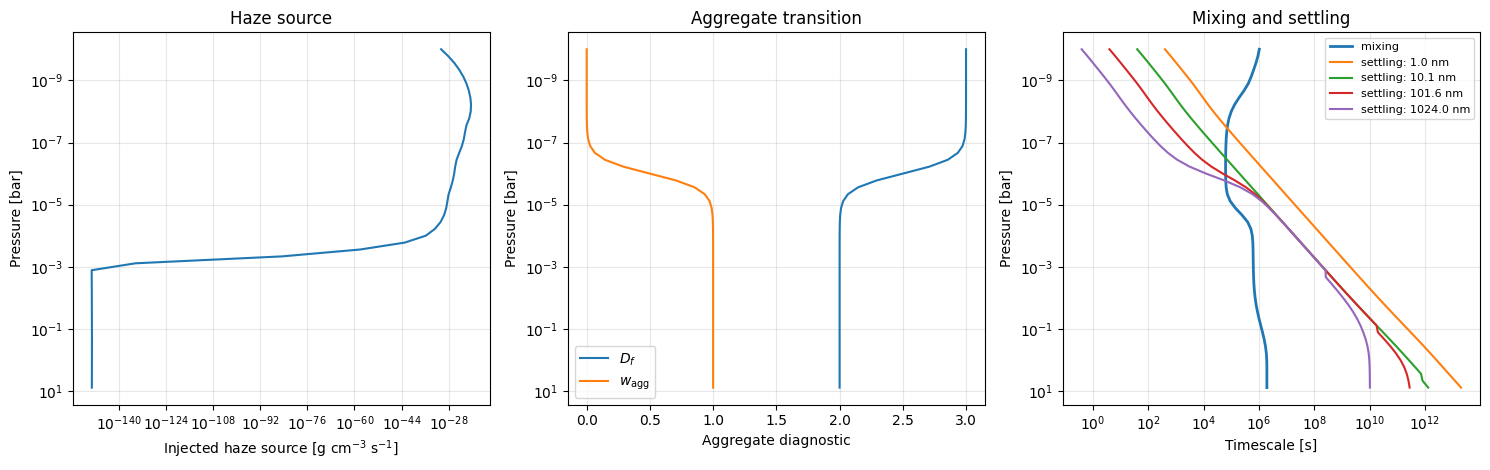

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

ax = axes[0]
ax.plot(np.maximum(ctx["S_mass_density"], 1e-300), ctx["Pbar"])
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel(r"Injected haze source [g cm$^{-3}$ s$^{-1}$]")
ax.set_ylabel("Pressure [bar]")
ax.set_title("Haze source")
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(ctx["Df_layer"], ctx["Pbar"], label=r"$D_f$")
ax.plot(ctx["w_agg_layer"], ctx["Pbar"], label=r"$w_{\rm agg}$")
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel("Aggregate diagnostic")
ax.set_ylabel("Pressure [bar]")
ax.set_title("Aggregate transition")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(ctx["t_mix"], ctx["Pbar"], linewidth=2, label="mixing")

for radius_nm in [1.0, 10.0, 100.0, 1000.0]:
    i = int(np.argmin(np.abs(ctx["r_compact_nm"] - radius_nm)))
    ax.plot(
        ctx["t_set_bin"][:, i],
        ctx["Pbar"],
        label=f"settling: {ctx['r_compact_nm'][i]:.1f} nm",
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel("Timescale [s]")
ax.set_ylabel("Pressure [bar]")
ax.set_title("Mixing and settling")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 18. Run the full haze solver

This is the main event.

The next cell starts from an empty haze atmosphere and evolves the full microphysics model toward a steady state. Depending on the settings and the particle-growth rate, this can take several hours.

The solver prints one summary after each time chunk. The most useful values to watch are the haze column mass, source and sink fluxes, storage ratio, profile change, peak pressure, settling substeps, and coagulation substeps.

In [ ]:
print("Running the full Caligo microphysics model...")
start = time.time()

result = case.run_microphysics(
    prepare_context=False,
    with_coagulation=True,
    verbose=True,
)

print(f"Microphysics finished in {(time.time() - start) / 60.0:.2f} min")
print("Converged:", result["converged"])
print("Final model time [days]:", result["t_final"] / 86400.0)
print("Haze column mass [g cm^-2]:", result["column_mass"])
print("Peak haze pressure [bar]:", result["peak_pressure"])
print("Number-weighted radius [nm]:", result["number_weighted_radius_nm"])
print("Mass-weighted radius [nm]:", result["mass_weighted_radius_nm"])
print("Recycled-gas column [g cm^-2]:",
      result.get("recycled_gas_column", 0.0))

Running the full Caligo microphysics model...

CALIGO: FULL MICROPHYSICS INTEGRATION
dt_init = 1.000e+02 s
dt_growth = 1.030e+00
dt_max = 3.000e+02 s
chunk_time = 1.000e+05 s
max_chunks = 200
max_column_jump_frac = 1.000e+00

--- Chunk 1/200 ---
t = 1.000e+05 s (1.157e+00 d)
steps in chunk = 350
column mass = 9.812e-09 g cm^-2
F_source = 1.000e-13 g cm^-2 s^-1
F_sink = 1.877e-15 g cm^-2 s^-1
F_bottom = 2.178e-60 g cm^-2 s^-1
F_thermal = 1.877e-15 g cm^-2 s^-1
F_deep = 0.000e+00 g cm^-2 s^-1
F_storage = 9.812e-14 g cm^-2 s^-1
storage_ratio = 9.812e-01
balance_ratio = 9.812e-01
profile_change = 1.000e+00
peak_pressure = 2.774e-08 bar
peak_shift_dex = 2.887e+00
max_sed_substeps = 7
coag_substeps total = 638
max_coag_substeps = 3
coag_active_layers = 17
max_coag_max_dtl = 8.148e-02
stable_chunks = 0

--- Chunk 2/200 ---
t = 2.000e+05 s (2.315e+00 d)
steps in chunk = 335
column mass = 1.926e-08 g cm^-2
F_source = 1.000e-13 g cm^-2 s^-1
F_sink = 5.526e-15 g cm^-2 s^-1
F_bottom = 1.336e-52 g 

## 19. Read the summary and convergence history

The result dictionary holds the final state of the haze model.

Some of the most useful outputs are:

- `result["n"]`: particle number density in every atmospheric layer and size bin.
- `result["mass_density"]`: total haze mass density in each atmospheric layer.
- `result["mass_by_bin"]`: haze column mass in each size bin.
- `result["history"]`: chunk-by-chunk convergence diagnostics.
- `result["ctx"]`: the full microphysics context.

The history table is especially useful for a production run because it shows whether the source, sinks, and storage rate are moving toward balance.

In [ ]:
case.summary(result)

hist_df = diag.history_table(result=result)

history_cols = [
    "chunk",
    "t_end",
    "column_mass",
    "F_source",
    "F_sink",
    "F_bottom",
    "F_thermal",
    "F_deep",
    "F_storage",
    "storage_ratio",
    "balance_ratio",
    "profile_change",
    "peak_pressure",
    "coag_substeps",
    "max_coag_substeps",
    "max_coag_max_dtl",
    "max_sed_substeps",
]

available_cols = [
    column
    for column in history_cols
    if column in hist_df.columns
]

display(hist_df[available_cols].tail(10))


CALIGO SUMMARY
Context:
  n_pressure = 50
  n_bin      = 40
  P range    = [1.000e-10, 7.642e+00] bar
  T range    = [488.3, 868.4] K
  Kzz range  = [1.000e+08, 1.000e+09] cm^2/s
  mu range   = [1.139, 4.672]
  v_set max  = 6.581e+08 cm/s
  K_coag max = 1.096e+01 cm^3/s

Source:
  F_src        = 1.000e-13 g cm^-2 s^-1
  F_vol_source = 1.000e-13 g cm^-2 s^-1
  F_top_source = 0.000e+00 g cm^-2 s^-1
  F_photochem_raw = 5.980e-13 g cm^-2 s^-1
  precursors = ['C2H2', 'HCN']

Solver:
  converged = True
  t_final   = 5.200e+06 s = 6.019e+01 days
  recycled gas column = 0.000e+00 g cm^-2
  haze column mass    = 2.102e-07 g cm^-2
  peak haze pressure  = 5.953e-05 bar
  number-weighted radius = 1.587e+00 nm
  mass-weighted radius   = 1.813e+01 nm
  active bins = 0–22 (1.000e+00–1.613e+02 nm)

Last chunk:
  chunk              = 52
  column_mass        = 2.102e-07 g cm^-2
  F_source           = 1.000e-13 g cm^-2 s^-1
  F_sink             = 9.325e-14 g cm^-2 s^-1
  F_bottom           = 9.331e-23 g

,chunk,t_end,column_mass,F_source,F_sink,F_bottom,F_thermal,F_deep,F_storage,storage_ratio,balance_ratio,profile_change,peak_pressure,coag_substeps,max_coag_substeps,max_coag_max_dtl,max_sed_substeps
42,43,4300000.0,2.018890e-07,1.000000e-13,8.706112e-14,5.250018e-23,8.706112e-14,0.0,1.293888e-14,0.129389,0.129389,0.006409,0.000036,28530,98,2.944288,5
43,44,4400000.0,2.030964e-07,1.000000e-13,8.792629e-14,5.721925e-23,8.792629e-14,0.0,1.207371e-14,0.120737,0.120737,0.005946,0.000036,32683,98,2.943919,5
44,45,4500000.0,2.042220e-07,1.000000e-13,8.874322e-14,6.194844e-23,8.874322e-14,0.0,1.125678e-14,0.112568,0.112568,0.005514,0.000036,32682,98,2.943545,5
45,46,4600000.0,2.052707e-07,1.000000e-13,8.951340e-14,6.665889e-23,8.951340e-14,0.0,1.048660e-14,0.104866,0.104866,0.005111,0.000036,32682,98,2.943221,5
46,47,4700000.0,2.062468e-07,1.000000e-13,9.023865e-14,7.132583e-23,9.023865e-14,0.0,9.761350e-15,0.097613,0.097613,0.004736,0.000036,34511,109,3.270552,5
47,48,4800000.0,2.071548e-07,1.000000e-13,9.092037e-14,7.592434e-23,9.092037e-14,0.0,9.079635e-15,0.090796,0.090796,0.004385,0.000036,36350,109,3.270353,5
48,49,4900000.0,2.079987e-07,1.000000e-13,9.156095e-14,8.043807e-23,9.156095e-14,0.0,8.439051e-15,0.084391,0.084391,0.004057,0.000036,36349,109,3.270367,5
49,50,5000000.0,2.087825e-07,1.000000e-13,9.216214e-14,8.484958e-23,9.216214e-14,0.0,7.837858e-15,0.078379,0.078379,0.003754,0.000036,36349,109,3.270345,5
50,51,5100000.0,2.095099e-07,1.000000e-13,9.272571e-14,8.914414e-23,9.272571e-14,0.0,7.274293e-15,0.072743,0.072743,0.003472,0.000036,36349,109,3.270290,5
51,52,5200000.0,2.101846e-07,1.000000e-13,9.325343e-14,9.330946e-23,9.325343e-14,0.0,6.746571e-15,0.067466,0.067466,0.003210,0.000036,36349,109,3.270216,5


## 20. Save the expensive part

The time integration is the expensive part of the calculation, so we want to save it before doing anything fancy.

The NPZ file stores the main arrays. The CSV file stores the convergence history. The text file gives a readable summary that is convenient for checking an old run without reopening the notebook.

In [ ]:
output_dir = PROJECT_ROOT / "outputs" / RUN_LABEL
output_dir.mkdir(parents=True, exist_ok=True)

npz_path = output_dir / f"{RUN_LABEL}_result.npz"
csv_path = output_dir / f"{RUN_LABEL}_history.csv"
txt_path = output_dir / f"{RUN_LABEL}_summary.txt"

diag.save_result_npz(result, npz_path)
diag.save_history_csv(result=result, filename=csv_path)
diag.save_summary_txt(case, result=result, filename=txt_path)

print("Saved:")
print(" ", npz_path)
print(" ", csv_path)
print(" ", txt_path)

loaded = diag.load_result_npz(npz_path)

print("\nReload check:")
print("  n shape:", loaded["n"].shape)
print("  column mass:", loaded["column_mass"])
print("  final time:", loaded["t_final"])

Saved:
  /Users/svc553/Documents/Caligo/outputs/gj1214b_full_production/gj1214b_full_production_result.npz
  /Users/svc553/Documents/Caligo/outputs/gj1214b_full_production/gj1214b_full_production_history.csv
  /Users/svc553/Documents/Caligo/outputs/gj1214b_full_production/gj1214b_full_production_summary.txt

Reload check:
  n shape: (50, 40)
  column mass: 2.1018458461066358e-07
  final time: 5200000.0


## 21. Plot the main microphysics outputs

These are the plots I would look at first after a finished production run:

1. Haze mass density versus pressure.
2. Column haze mass distributed across particle sizes.
3. Source, sink, and storage fluxes through time.
4. Total haze column through time.
5. The pressure-radius haze-mass map.

Together, they show where the haze lives, how large the particles become, how the column approaches steady state, and whether the final mass distribution looks physically coherent.

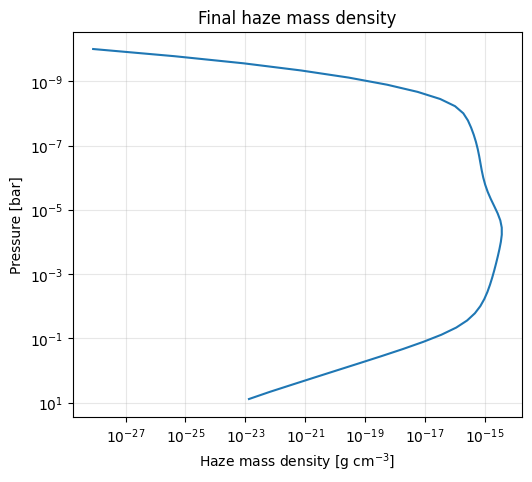

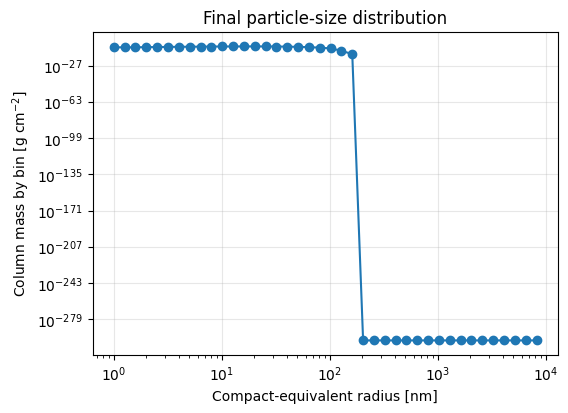

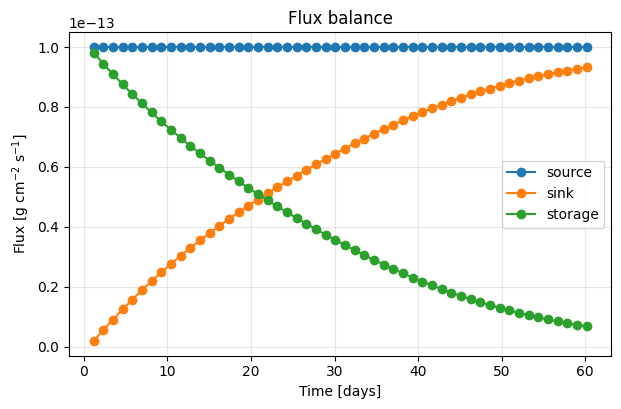

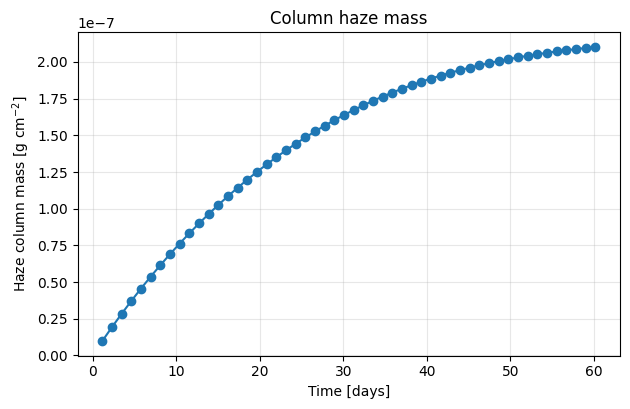

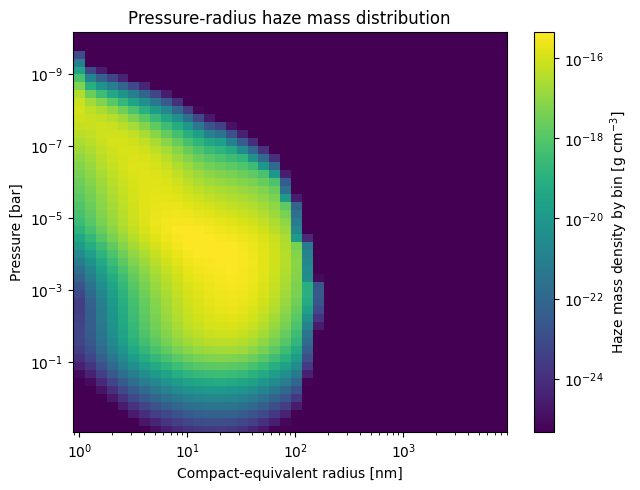

In [ ]:
ctx = result["ctx"]
t_days = hist_df["t_end"].values / 86400.0

fig, ax = plt.subplots(figsize=(5.8, 5.0))
ax.loglog(np.maximum(result["mass_density"], 1e-300), result["Pbar"])
ax.invert_yaxis()
ax.set_xlabel(r"Haze mass density [g cm$^{-3}$]")
ax.set_ylabel("Pressure [bar]")
ax.set_title("Final haze mass density")
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(6.0, 4.2))
ax.loglog(
    result["r_compact_nm"],
    np.maximum(result["mass_by_bin"], 1e-300),
    marker="o",
)
ax.set_xlabel("Compact-equivalent radius [nm]")
ax.set_ylabel(r"Column mass by bin [g cm$^{-2}$]")
ax.set_title("Final particle-size distribution")
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(t_days, hist_df["F_source"].values, marker="o", label="source")
ax.plot(t_days, hist_df["F_sink"].values, marker="o", label="sink")
ax.plot(t_days, hist_df["F_storage"].values, marker="o", label="storage")
ax.set_xlabel("Time [days]")
ax.set_ylabel(r"Flux [g cm$^{-2}$ s$^{-1}$]")
ax.set_title("Flux balance")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(t_days, hist_df["column_mass"].values, marker="o")
ax.set_xlabel("Time [days]")
ax.set_ylabel(r"Haze column mass [g cm$^{-2}$]")
ax.set_title("Column haze mass")
ax.grid(alpha=0.3)
plt.show()

mass_density_bin = result["n"] * ctx["m_bin"][None, :]

positive = mass_density_bin[mass_density_bin > 0]
vmax = np.max(positive) if positive.size else 1.0
vmin = max(vmax * 1e-10, 1e-300)

fig, ax = plt.subplots(figsize=(7.0, 5.2))
mesh = ax.pcolormesh(
    ctx["r_compact_nm"],
    ctx["Pbar"],
    np.maximum(mass_density_bin, vmin),
    shading="auto",
    norm=LogNorm(vmin=vmin, vmax=vmax),
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel("Compact-equivalent radius [nm]")
ax.set_ylabel("Pressure [bar]")
ax.set_title("Pressure-radius haze mass distribution")
cb = fig.colorbar(mesh, ax=ax)
cb.set_label(r"Haze mass density by bin [g cm$^{-3}$]")
plt.show()

## 22. Compare the process timescales

This is one of the most useful diagnostic plots in the whole notebook.

The mixing timescale is estimated from $H^2/K_{zz}$.

The settling timescale is estimated from $H/v_{\rm set}$ after weighting the settling speed by the local haze mass distribution.

The coagulation timescale comes from the local collision frequencies calculated with the final particle distribution.

The thermal-destruction timescale is the inverse of the parameterized thermal-loss rate.

The point is not that one process wins everywhere. The interesting part is seeing where the dominant balance changes with pressure.

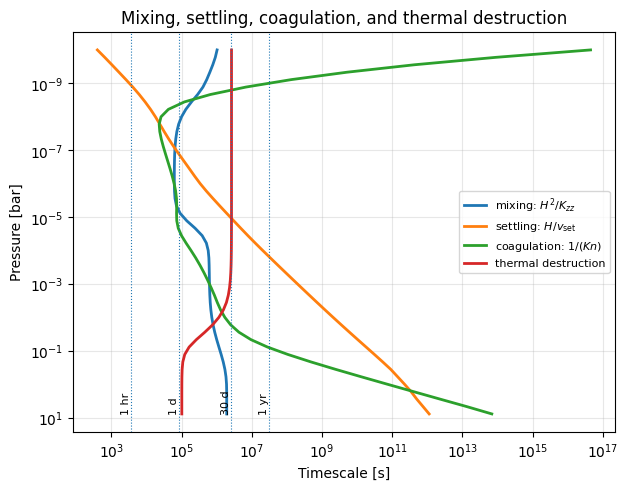

In [ ]:
n = np.asarray(result["n"], dtype=float)
m_bin = np.asarray(ctx["m_bin"], dtype=float)

mass_density_bin = n * m_bin[None, :]
mass_density_layer = np.sum(mass_density_bin, axis=1)
number_density_layer = np.sum(n, axis=1)

active = mass_density_layer > max(np.max(mass_density_layer) * 1e-30, 1e-300)

tau_mix = ctx["H"]**2 / np.maximum(ctx["Kzz"], 1e-300)

v_mass = (
    np.sum(mass_density_bin * ctx["v_set"], axis=1)
    / np.maximum(mass_density_layer, 1e-300)
)
tau_set = ctx["H"] / np.maximum(v_mass, 1e-300)
tau_set[~active] = np.nan

freq_i = np.einsum("kij,kj->ki", ctx["K_coag"], n)
freq_eff = (
    np.sum(n * freq_i, axis=1)
    / np.maximum(number_density_layer, 1e-300)
)
tau_coag = 1.0 / np.maximum(freq_eff, 1e-300)
tau_coag[~active] = np.nan

tau_therm = 1.0 / np.maximum(ctx["thermal_sink_rate"], 1e-300)
tau_therm[~active] = np.nan

fig, ax = plt.subplots(figsize=(7.0, 5.2))
ax.plot(tau_mix, ctx["Pbar"], linewidth=2, label=r"mixing: $H^2/K_{zz}$")
ax.plot(tau_set, ctx["Pbar"], linewidth=2, label=r"settling: $H/v_{\rm set}$")
ax.plot(tau_coag, ctx["Pbar"], linewidth=2, label=r"coagulation: $1/(Kn)$")
ax.plot(tau_therm, ctx["Pbar"], linewidth=2, label="thermal destruction")

for tref, label in [
    (3600.0, "1 hr"),
    (86400.0, "1 d"),
    (30.0 * 86400.0, "30 d"),
    (365.0 * 86400.0, "1 yr"),
]:
    ax.axvline(tref, linestyle=":", linewidth=0.8)
    ax.text(
        tref,
        np.max(ctx["Pbar"]),
        label,
        rotation=90,
        fontsize=8,
        va="bottom",
        ha="right",
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_yaxis()
ax.set_xlabel("Timescale [s]")
ax.set_ylabel("Pressure [bar]")
ax.set_title("Mixing, settling, coagulation, and thermal destruction")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## 23. Run a final numerical health check

Before treating the result as a real model output, it is worth checking the numerical basics.

A healthy production run should keep the particle distribution finite and non-negative. The chunk-level mass errors should remain small, and the final history row should include a complete flux budget.

The convergence flag is also important. If it is false, the model still produced a valid saved state, but it did not meet the requested steady-state criteria within the allowed number of chunks.

In [ ]:
last = result["last_chunk"]

checks = {
    "Result is a dictionary": isinstance(result, dict),
    "Particle densities are finite": np.all(np.isfinite(result["n"])),
    "Particle densities are non-negative": np.all(result["n"] >= 0),
    "Haze column is positive": result["column_mass"] > 0,
    "History table is not empty": len(result["history"]) > 0,
    "Last chunk includes a flux budget": all(
        key in last
        for key in [
            "F_source",
            "F_sink",
            "F_storage",
            "storage_ratio",
            "balance_ratio",
        ]
    ),
    "Chunk mass errors are small": all(
        abs(chunk.get("max_rel_mass_error", 0.0)) < 1e-8
        for chunk in result["history"]
    ),
}

print("Numerical health check:")

for name, passed in checks.items():
    print(f"  {name}: {bool(passed)}")

print("\nFinal flux budget:")

for key in [
    "F_source",
    "F_sink",
    "F_bottom",
    "F_thermal",
    "F_deep",
    "F_storage",
    "storage_ratio",
    "balance_ratio",
    "profile_change",
    "peak_pressure",
]:
    print(f"  {key}: {last.get(key)}")

Numerical health check:
  Result is a dictionary: True
  Particle densities are finite: True
  Particle densities are non-negative: True
  Haze column is positive: True
  History table is not empty: True
  Last chunk includes a flux budget: True
  Chunk mass errors are small: True

Final flux budget:
  F_source: 1.0000000000000129e-13
  F_sink: 9.325342863064119e-14
  F_bottom: 9.330945844757444e-23
  F_thermal: 9.325342853733172e-14
  F_deep: 0.0
  F_storage: 6.746571369321115e-15
  storage_ratio: 0.06746571369321115
  balance_ratio: 0.06746571369360102
  profile_change: 0.0032098316733448384
  peak_pressure: 3.5698465288140735e-05


## 24. Where to go next

This notebook intentionally runs one clean baseline from start to finish.

Once the baseline is saved, the easiest next step is to copy the configured case and change one assumption at a time. Useful comparisons include:

- aggregates versus compact spheres,
- charged versus neutral particles,
- coagulation on versus off,
- photochemical versus Gaussian source layers,
- different haze-source fluxes,
- different $K_{zz}$ profiles,
- different thermal-destruction timescales.

If only a microphysics setting changes, a copied case can reuse the existing photochem result.

If the reaction network, stellar spectrum, metallicity, carbon-to-oxygen ratio, precursor list, or yield model changes, rebuild the relevant chemistry and source steps first.

## 25. Where optical properties fit into the workflow

The core Caligo package stops at the particle microphysics.

It gives us the vertical number-density distribution, haze mass distribution, particle radii, aggregate properties, source and sink fluxes, convergence history, and timescale diagnostics.

From there, we can calculate haze optical properties using a refractive-index file and a chosen opacity treatment. Those opacity products can then be passed into a radiative-transfer workflow for spectra.

Keeping that step separate is useful. It lets us study the microphysics without locking the package to one refractive-index dataset or one optical prescription.

## 26. Quick option map

Here is the short version of the settings we are most likely to change.

### Vertical source

- **photochem** follows the precursor photolysis profile.
- **gaussian** uses a controlled source layer.

### Total source strength

- Fixed-flux mode enforces a chosen haze-production flux.
- Photochem-scaled mode uses the raw photochemical source multiplied by a scale factor.

### Fresh particle sizes

- **single bin** puts all new haze into one size bin.
- **lognormal** gives the fresh particles a narrow size spread.
- **custom weights** lets us define the full starting distribution manually.

### Particle structure

- Aggregates on allows porous fractal particles.
- Aggregates off gives compact spheres.

### Coagulation

- Brownian growth is the baseline.
- Differential settling can be added.
- Charge suppression can be turned on or off.

### Lower boundary

- Deposition velocity includes diffusive deposition and settling.
- Open flux uses settling only.
- Zero flux closes the bottom boundary.

### Internal removal

- Smooth thermal destruction removes haze in hot layers.
- Deep recycling adds an optional unresolved deep-atmosphere sink.

### Solver behavior

- The production settings shown here are intended for a converged scientific run.

In [ ]:
from pathlib import Path
import json
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from caligo import optics as copt

importlib.reload(copt)

REFRIND_FILE = Path(
    "/Users/svc553/virga/virga/lab_ref_mieff/ExoHaze1000xSolar_300K.refrind"
)

diagnostic_dir = output_dir / "direct_mie_picaso_spectrum" / "bin_diagnostics"
diagnostic_dir.mkdir(parents=True, exist_ok=True)

print("Running bin-level optical-depth diagnostics...")
print("This recomputes the optics only. It does not rerun microphysics.")

aggregate_contrib = copt.compute_tau_contribution_by_bin(
    result=result,
    refractive_index_file=REFRIND_FILE,
    optics_mode="aggregate_effective_mie",
    n_wavelength=180,
    verbose=True,
)

compact_contrib = copt.compute_tau_contribution_by_bin(
    result=result,
    refractive_index_file=REFRIND_FILE,
    optics_mode="compact_mie",
    wavelength_um=aggregate_contrib["wavelength_um"],
    verbose=True,
)

comparison = copt.compare_compact_and_aggregate_optics(
    result=result,
    refractive_index_file=REFRIND_FILE,
    wavelength_um=aggregate_contrib["wavelength_um"],
    verbose=True,
)


def contribution_dataframe(contribution):
    return pd.DataFrame(
        {
            "bin": np.arange(len(contribution["compact_radius_nm"])),
            "compact_radius_nm": contribution["compact_radius_nm"],
            "representative_optical_radius_nm": contribution["radius_nm_by_bin"],
            "number_column_cm2": contribution["number_column_by_bin"],
            "mass_column_g_cm2": contribution["mass_column_by_bin"],
            "tau_at_peak_wavelength": contribution["tau_by_bin_at_peak"],
            "tau_fraction_at_peak_wavelength": contribution["tau_fraction_by_bin_at_peak"],
            "tau_integrated_over_sampled_wavelengths": contribution["tau_by_bin_integrated"],
            "tau_fraction_integrated_over_sampled_wavelengths": contribution["tau_fraction_by_bin_integrated"],
        }
    )


def print_top_contributors(contribution, label, n=8):
    df = contribution_dataframe(contribution)

    print("\n" + "=" * 70)
    print(f"Top optical-depth contributors: {label}")
    print("=" * 70)
    print("Peak wavelength [um]:", contribution["peak_wavelength_um"])
    print("Max vertical tau:", np.max(contribution["vertical_tau"]))

    display(
        df.sort_values(
            "tau_fraction_at_peak_wavelength",
            ascending=False,
        )
        .head(n)
        .reset_index(drop=True)
    )

    giant_mask = df["representative_optical_radius_nm"] > 1e4

    print(
        "Fraction of peak-wavelength tau from particles with "
        "representative optical radius > 10,000 nm:",
        df.loc[
            giant_mask,
            "tau_fraction_at_peak_wavelength",
        ].sum(),
    )

    print(
        "Fraction of wavelength-integrated tau from particles with "
        "representative optical radius > 10,000 nm:",
        df.loc[
            giant_mask,
            "tau_fraction_integrated_over_sampled_wavelengths",
        ].sum(),
    )


compact_df = contribution_dataframe(compact_contrib)
aggregate_df = contribution_dataframe(aggregate_contrib)

compact_csv = diagnostic_dir / f"{RUN_LABEL}_compact_mie_tau_by_bin.csv"
aggregate_csv = diagnostic_dir / f"{RUN_LABEL}_aggregate_effective_mie_tau_by_bin.csv"
comparison_json = diagnostic_dir / f"{RUN_LABEL}_compact_vs_aggregate_optics_comparison.json"

compact_df.to_csv(compact_csv, index=False)
aggregate_df.to_csv(aggregate_csv, index=False)

with open(comparison_json, "w") as handle:
    json.dump(
        {
            key: float(value)
            for key, value in comparison["diag"].items()
        },
        handle,
        indent=2,
    )

print_top_contributors(compact_contrib, "compact_mie")
print_top_contributors(aggregate_contrib, "aggregate_effective_mie")


fig, ax = plt.subplots(figsize=(7.4, 4.8))

ax.plot(
    compact_contrib["radius_nm_by_bin"],
    np.maximum(
        compact_contrib["tau_fraction_by_bin_at_peak"],
        1e-14,
    ),
    marker="o",
    label=f"compact Mie, peak {compact_contrib['peak_wavelength_um']:.3g} µm",
)

ax.plot(
    aggregate_contrib["radius_nm_by_bin"],
    np.maximum(
        aggregate_contrib["tau_fraction_by_bin_at_peak"],
        1e-14,
    ),
    marker="o",
    label=f"aggregate effective Mie, peak {aggregate_contrib['peak_wavelength_um']:.3g} µm",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Representative optical radius [nm]")
ax.set_ylabel("Fraction of optical depth at peak wavelength")
ax.set_title("Which particle bins control the peak haze opacity?")
ax.legend()
ax.grid(alpha=0.3, which="both")

peak_bin_png = diagnostic_dir / f"{RUN_LABEL}_tau_fraction_by_bin_at_peak.png"
fig.savefig(peak_bin_png, dpi=200, bbox_inches="tight")

plt.show()


fig, ax = plt.subplots(figsize=(4.8, 4.8))

ax.plot(
    compact_contrib["radius_nm_by_bin"],
    np.maximum(
        compact_contrib["tau_fraction_by_bin_integrated"],
        1e-14,
    ),
    marker="o",
    label="compact Mie",
)

ax.plot(
    aggregate_contrib["radius_nm_by_bin"],
    np.maximum(
        aggregate_contrib["tau_fraction_by_bin_integrated"],
        1e-14,
    ),
    marker="o",
    label="aggregate effective Mie",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Representative optical radius [nm]")
ax.set_ylabel("Fraction of summed optical depth")
ax.set_title("Which particle bins control total sampled haze opacity?")
ax.legend()
ax.grid(alpha=0.3, which="both")

integrated_bin_png = diagnostic_dir / f"{RUN_LABEL}_tau_fraction_by_bin_integrated.png"
fig.savefig(integrated_bin_png, dpi=200, bbox_inches="tight")

plt.show()


fig, ax = plt.subplots(figsize=(7.6, 4.8))

copt.plot_compact_vs_aggregate_tau(
    comparison,
    ax=ax,
)

tau_comparison_png = diagnostic_dir / f"{RUN_LABEL}_compact_vs_aggregate_vertical_tau.png"
fig.savefig(tau_comparison_png, dpi=200, bbox_inches="tight")

plt.show()


fig, ax = plt.subplots(figsize=(7.6, 4.2))

copt.plot_compact_vs_aggregate_ratio(
    comparison,
    ax=ax,
)

ratio_png = diagnostic_dir / f"{RUN_LABEL}_aggregate_over_compact_tau_ratio.png"
fig.savefig(ratio_png, dpi=200, bbox_inches="tight")

plt.show()


print("\nBin diagnostics complete.")
print("Saved diagnostic outputs in:", diagnostic_dir)
print("Compact bin table:", compact_csv)
print("Aggregate-effective bin table:", aggregate_csv)
print("Comparison JSON:", comparison_json)
print("Peak-bin plot:", peak_bin_png)
print("Integrated-bin plot:", integrated_bin_png)
print("Vertical tau comparison plot:", tau_comparison_png)
print("Tau ratio plot:", ratio_png)

NameError: name 'output_dir' is not defined

In [13]:
import os
import glob
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# USER SETTINGS
# ============================================================
DATA_DIR = "/Users/svc553/Documents/Sub-Neptune/Gj1214b_data"
OPTICS_ROOT = "/Users/svc553/Documents/Sub-Neptune/Gj1214b_data/optics_from_saved_microphysics"

RUN_LABEL = "photochem_y0p05_raw_photochem_flux"
# RUN_LABEL = "photochem_y0p10_fixed_m12"
# RUN_LABEL = "photochem_y0p30_raw_photochem_flux"

OPTICS_FOLDERS = [
    "Soot_Lavvass",
    "khare_tholins",
    "JHU013123_500K_2000_solar",
]

# model offset in percent units
MODEL_OFFSET_PCT = 0.270

# keep only these data sets by filename substring
INCLUDE_ONLY_FILES = [
    "Kreidberg",
    "Edwards",
    "Schlawin",
]

XMIN = 0.3
XMAX = 6.0
YMIN = None
YMAX = None

SAVE_FIG = False
SAVE_PATH = os.path.join(DATA_DIR, f"{RUN_LABEL}_paper_compare.png")


plt.rcParams.update({
    "figure.figsize": (10.5, 7.0),
    "font.size": 12,
    "axes.titlesize": 22,
    "axes.labelsize": 17,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.linewidth": 1.0,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.8,
    "grid.linestyle": "-",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "savefig.dpi": 300,
})

# ============================================================
# HELPERS
# ============================================================
def safe_numeric_convert(series):
    try:
        return pd.to_numeric(series)
    except Exception:
        return series

def read_exoplanet_archive_tbl(filepath):
    meta = {}
    header_cols = None
    data_rows = []

    with open(filepath, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        s = line.strip()

        if not s:
            continue

        if s.startswith("\\") and "=" in s:
            key, val = s[1:].split("=", 1)
            meta[key.strip()] = html.unescape(val.strip())
            continue

        if s == "\\":
            continue

        if s.startswith("|CENTRALWAVELNG|"):
            header_cols = [x.strip() for x in s.strip("|").split("|")]
            continue

        if s.startswith("|"):
            continue

        if header_cols is not None:
            parts = s.split()
            if len(parts) < len(header_cols):
                continue
            data_rows.append(parts[:len(header_cols)])

    if header_cols is None:
        raise ValueError(f"Could not find table header in {filepath}")

    df = pd.DataFrame(data_rows, columns=header_cols)
    for col in df.columns:
        df[col] = safe_numeric_convert(df[col])

    return meta, df

def shorten_label(meta):
    ref = html.unescape(str(meta.get("REFERENCE", "Unknown Ref")))
    inst = html.unescape(str(meta.get("INSTRUMENT", "Unknown Instrument")))

    inst = (
        inst.replace("Wide Field Camera 3", "WFC3")
            .replace("Near Infrared Spectrograph", "NIRSpec")
            .replace("Near Infrared Camera", "NIRCam")
            .replace("Mid-Infrared Instrument", "MIRI")
    )
    return f"{ref} | {inst}"

def read_model_spectrum_file(filepath):
    df = pd.read_csv(filepath, sep=None, engine="python")

    x = pd.to_numeric(df["wavelength_micron"], errors="coerce").to_numpy(dtype=float)

    if "transit_depth" in df.columns:
        y = pd.to_numeric(df["transit_depth"], errors="coerce").to_numpy(dtype=float)
        if np.nanmax(y) < 1.0:
            y = y * 100.0
    elif "transit_depth_ppm" in df.columns:
        y = pd.to_numeric(df["transit_depth_ppm"], errors="coerce").to_numpy(dtype=float) / 1e4
    else:
        raise ValueError(f"No recognized transit depth column in {filepath}")

    good = np.isfinite(x) & np.isfinite(y)
    return x[good], y[good]

def find_model_file(optics_folder, run_label):
    case_dir = os.path.join(OPTICS_ROOT, optics_folder, run_label)
    print(f"Looking in: {case_dir}")

    if not os.path.isdir(case_dir):
        print("  -> case directory does not exist")
        return None

    candidates = sorted(glob.glob(os.path.join(case_dir, "*_spectrum.txt")))
    print(f"  -> found {len(candidates)} spectrum txt files")

    if len(candidates) == 0:
        return None

    preferred = [fp for fp in candidates if os.path.basename(fp).startswith(run_label)]
    if len(preferred) > 0:
        print(f"  -> using preferred file: {os.path.basename(preferred[0])}")
        return preferred[0]

    print(f"  -> using first candidate: {os.path.basename(candidates[0])}")
    return candidates[0]

def model_display_name(folder_name):
    mapping = {
        "Soot_Lavvass": "Soot_Lavvas[s]",
        "khare_tholins": "Khare tholins",
        "JHU013123_500K_2000_solar": "JHU 500K 2000x solar",
        "h2so4": r"H$_2$SO$_4$",
    }
    return mapping.get(folder_name, folder_name)

# ============================================================
# LOAD DATA
# ============================================================
# ============================================================
# LOAD DATA
# ============================================================
tbl_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.tbl")))
if len(tbl_files) == 0:
    raise FileNotFoundError(f"No .tbl files found in {DATA_DIR}")

print(f"Found {len(tbl_files)} .tbl files")

spectra = []
for fp in tbl_files:
    try:
        meta, df = read_exoplanet_archive_tbl(fp)

        ref = html.unescape(str(meta.get("REFERENCE", "")))
        inst = html.unescape(str(meta.get("INSTRUMENT", "")))
        label = shorten_label(meta)

        # ----------------------------------------------------
        # filter by METADATA, not filename
        # ----------------------------------------------------
        if INCLUDE_ONLY_FILES:
            keep = any(tag.lower() in ref.lower() or tag.lower() in inst.lower()
                       for tag in INCLUDE_ONLY_FILES)
            if not keep:
                continue

        x = pd.to_numeric(df["CENTRALWAVELNG"], errors="coerce").to_numpy(dtype=float)
        y = pd.to_numeric(df["PL_TRANDEP"], errors="coerce").to_numpy(dtype=float)
        yerr = np.abs(pd.to_numeric(df["PL_TRANDEPERR1"], errors="coerce").to_numpy(dtype=float))

        good = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr)
        x = x[good]
        y = y[good]
        yerr = yerr[good]

        if len(x) == 0:
            continue

        spectra.append({
            "label": label,
            "x": x,
            "y": y,
            "yerr": yerr,
            "file": os.path.basename(fp),
            "reference": ref,
            "instrument": inst,
        })

        print(f"Loaded: {os.path.basename(fp)}  ->  {label}")

    except Exception as e:
        print(f"Could not read {os.path.basename(fp)}: {e}")

print(f"\nLoaded {len(spectra)} data spectra after metadata filtering")

# ============================================================
# LOAD MODELS
# ============================================================
models = []
for folder in OPTICS_FOLDERS:
    fp = find_model_file(folder, RUN_LABEL)
    if fp is None:
        print(f"Missing model spectrum for {folder} / {RUN_LABEL}\n")
        continue

    try:
        x, y = read_model_spectrum_file(fp)
        models.append({
            "label": model_display_name(folder),
            "x": x,
            "y": y - MODEL_OFFSET_PCT,
            "y_raw": y,
            "file": fp,
        })
        print(f"Loaded model: {model_display_name(folder)}\n")
    except Exception as e:
        print(f"Could not read model file for {folder}: {e}\n")

print(f"Loaded {len(models)} model spectra\n")



Found 3 .tbl files
Loaded: GJ_1214_b_3.10969_3621_1.tbl  ->  Kreidberg et al. 2014 | WFC3
Loaded: GJ_1214_b_3.10969_5286_41.tbl  ->  Edwards et al. 2023 | WFC3
Loaded: GJ_1214_b_3.10969_5520_1.tbl  ->  Schlawin et al. 2024 | NIRSpec (NIRSpec)

Loaded 3 data spectra after metadata filtering
Looking in: /Users/svc553/Documents/Sub-Neptune/Gj1214b_data/optics_from_saved_microphysics/Soot_Lavvass/photochem_y0p05_raw_photochem_flux
  -> found 1 spectrum txt files
  -> using preferred file: photochem_y0p05_raw_photochem_flux_spectrum.txt
Loaded model: Soot_Lavvas[s]

Looking in: /Users/svc553/Documents/Sub-Neptune/Gj1214b_data/optics_from_saved_microphysics/khare_tholins/photochem_y0p05_raw_photochem_flux
  -> found 1 spectrum txt files
  -> using preferred file: photochem_y0p05_raw_photochem_flux_spectrum.txt
Loaded model: Khare tholins

Looking in: /Users/svc553/Documents/Sub-Neptune/Gj1214b_data/optics_from_saved_microphysics/JHU013123_500K_2000_solar/photochem_y0p05_raw_photochem_flux
  

Saved:
  /Users/svc553/Documents/Sub-Neptune/Gj1214b_data/proposal_figures/photochem_y0p05_raw_photochem_flux_proposal_clean_legend.png
  /Users/svc553/Documents/Sub-Neptune/Gj1214b_data/proposal_figures/photochem_y0p05_raw_photochem_flux_proposal_clean_legend.pdf


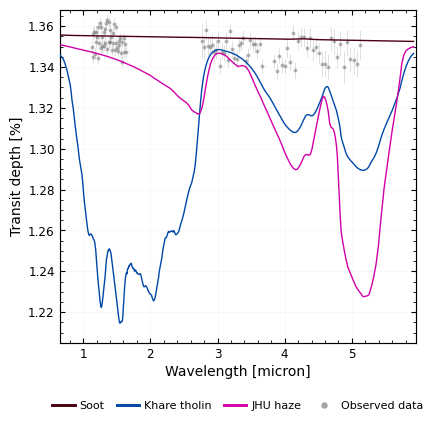

In [17]:
# ============================================================
# PROPOSAL-FRIENDLY COMPACT PLOT: CLEAN LEGEND, NO IN-PLOT TEXT
# ============================================================
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator

# ----------------------------
# Figure settings
# ----------------------------
XMIN = 0.65
XMAX = 5.95

YMIN = 1.205
YMAX = 1.368

FIGSIZE = (4.0, 4.5)

SAVE_FIG = True
SAVE_DIR = Path(DATA_DIR) / "proposal_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PATH_PNG = SAVE_DIR / f"{RUN_LABEL}_proposal_clean_legend.png"
SAVE_PATH_PDF = SAVE_DIR / f"{RUN_LABEL}_proposal_clean_legend.pdf"

SMOOTH_MODELS = True
SMOOTH_WINDOW = 7   # odd number; try 5, 7, or 9


# ----------------------------
# Helpers
# ----------------------------
def clean_model_label(label):
    label = str(label)

    mapping = {
        "Soot_Lavvas[s]": "Soot",
        "Soot Lavvas[s]": "Soot",
        "Khare tholins": "Khare tholin",
        "khare_tholins": "Khare tholin",
        "JHU 500K 2000x solar": "JHU haze",
        "JHU013123_500K_2000_solar": "JHU haze",
        "ExoHaze 1000x solar, 300 K": "ExoHaze",
    }

    return mapping.get(label, label.replace("_", " "))


def smooth_1d(y, window=7):
    y = np.asarray(y, dtype=float)

    if window is None or window <= 1:
        return y

    if window % 2 == 0:
        window += 1

    if len(y) < window:
        return y

    kernel = np.ones(window, dtype=float) / window
    y_pad = np.pad(y, window // 2, mode="edge")
    return np.convolve(y_pad, kernel, mode="valid")


# ----------------------------
# Colors
# ----------------------------
model_colors = {
    "Soot": "#4A0010",
    "Khare tholin": "#0047A8",
    "JHU haze": "#D100A8",
    "ExoHaze": "#D100A8",
}

data_color = "0.35"
data_error_color = "0.60"


# ----------------------------
# Style
# ----------------------------
plt.rcParams.update({
    "figure.figsize": FIGSIZE,
    "font.size": 8.6,
    "axes.labelsize": 10.0,
    "axes.titlesize": 10.0,
    "xtick.labelsize": 8.6,
    "ytick.labelsize": 8.6,
    "legend.fontsize": 8.0,
    "axes.linewidth": 0.85,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 400,
})


# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

model_handles = []

# model curves
for model in models:
    label = clean_model_label(model["label"])
    color = model_colors.get(label, "black")

    x = np.asarray(model["x"], dtype=float)
    y = np.asarray(model["y"], dtype=float)

    use = (x >= XMIN) & (x <= XMAX)

    x_plot = x[use]
    y_plot = y[use]

    if SMOOTH_MODELS:
        y_plot = smooth_1d(y_plot, window=SMOOTH_WINDOW)

    ax.plot(
        x_plot,
        y_plot,
        lw=1.0,
        color=color,
        zorder=3,
    )

    model_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            lw=2.1,
            label=label,
        )
    )

# observed data, muted and unlabeled inside panel
for spec in spectra:
    x = np.asarray(spec["x"], dtype=float)
    y = np.asarray(spec["y"], dtype=float)
    yerr = np.asarray(spec["yerr"], dtype=float)

    use = (x >= XMIN) & (x <= XMAX)

    ax.errorbar(
        x[use],
        y[use],
        yerr=yerr[use],
        fmt="o",
        markersize=2.8,
        markeredgewidth=0.2,
        markeredgecolor="white",
        elinewidth=0.5,
        capsize=0,
        alpha=0.45,
        color=data_color,
        ecolor=data_error_color,
        zorder=2,
    )

# axes
ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)

ax.set_xlabel("Wavelength [micron]", labelpad=3)
ax.set_ylabel("Transit depth [%]", labelpad=3)

# No title. Put the title/caption in the proposal text instead.
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.grid(alpha=0.10, linewidth=0.5)

for spine in ax.spines.values():
    spine.set_linewidth(0.85)

# one compact legend below the panel
data_handle = Line2D(
    [0],
    [0],
    marker="o",
    linestyle="None",
    markerfacecolor=data_color,
    markeredgecolor="white",
    markeredgewidth=0.2,
    markersize=4.7,
    alpha=0.55,
    label="Observed data",
)

handles = model_handles + [data_handle]

ax.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=4,
    frameon=False,
    handlelength=2.0,
    columnspacing=1.1,
    handletextpad=0.45,
    borderaxespad=0.0,
)

fig.subplots_adjust(
    left=0.095,
    right=0.985,
    top=0.985,
    bottom=0.245,
)

if SAVE_FIG:
    fig.savefig(SAVE_PATH_PNG, bbox_inches="tight", pad_inches=0.025)
    fig.savefig(SAVE_PATH_PDF, bbox_inches="tight", pad_inches=0.025)
    print("Saved:")
    print(" ", SAVE_PATH_PNG)
    print(" ", SAVE_PATH_PDF)

plt.show()